# Experiment 2 — Causal Discovery with OT-ICA: Sachs Protein Signalling Network

**Goal.** Evaluate OT-ICA as the unmixing engine inside ICA-LiNGAM, against the standard
FastICA solver, under a single identical post-processing pipeline.

**Design.**

| Part | Data | Ground truth | Purpose |
|---|---|---|---|
| A | Real Sachs (11 proteins, flow cytometry) | Consensus 17-edge network | Application; qualitative + quantitative |
| B | Semi-synthetic from the true Sachs DAG | Exact | Controlled comparison across noise regimes |

**Evaluation protocol.** Both solvers feed the *same* LiNGAM post-processing
(Hungarian row-matching on $1/|W_{ii}|$, diagonal normalisation, $\mathbf{B}=\mathbf{I}-\mathbf{W}$,
Shimizu Algorithm B for the causal order). Edges are scored at top-$k$ with $k = |E_{\text{true}}|$,
so neither method gets a tuned threshold. All results are averaged over 10 seeds.

**Metrics.**
- **F1 / precision / recall @ top-$k$** — edge recovery.
- **SHD** — structural Hamming distance (insertions + deletions + reversals).
- **AUC** — threshold-free ranking quality of $|B_{ij}|$.
- **Order consistency** — fraction of true edges $p \to c$ with $\mathrm{rank}(p) < \mathrm{rank}(c)$
  in the estimated causal order. Chance = 0.5. This is the quantity LiNGAM actually estimates.
- **Residual dependence** — mean $|\rho_{\text{Spearman}}|$ between $|s_i|, |s_j|$ over pairs.
  Ground-truth-free; detects the *location-scale* dependence that linear decorrelation cannot see.

In [1]:
# =====================================================================
# 0. IMPORTS, GLOBAL SEED, PLOT STYLE
# =====================================================================
import os, random, itertools, warnings
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyArrowPatch, FancyBboxPatch
from scipy.optimize import linear_sum_assignment
from scipy.stats import spearmanr, skew, kurtosis, shapiro
from sklearn.decomposition import FastICA
from sklearn.metrics import roc_auc_score

from wasserstein_ica import WassersteinICA

warnings.filterwarnings("ignore")

# ---------- UNIVERSAL SEED ----------
SEED = 42

def set_seed(seed: int = SEED):
    """Seed every RNG that can affect this notebook."""
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

set_seed(SEED)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"device = {DEVICE}   |   global seed = {SEED}")

# ---------- THESIS-QUALITY FIGURE STYLE ----------
plt.rcParams.update({
    "figure.dpi": 110,
    "savefig.dpi": 400,
    "savefig.bbox": "tight",
    "font.family": "serif",
    "font.serif": ["DejaVu Serif"],
    "mathtext.fontset": "dejavuserif",
    "font.size": 11,
    "axes.titlesize": 12,
    "axes.labelsize": 11,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.22,
    "grid.linewidth": 0.6,
    "legend.frameon": False,
})

# ---------- THESIS-CONSISTENT PALETTE ----------
PALETTE = {"FastICA": "#0173B2", "OT-ICA": "#D55E00"}   # blue / orange, as in Ch. 4-5
C_OT    = PALETTE["OT-ICA"]
C_FAST  = PALETTE["FastICA"]

C_DATA  = "#4A5A6A"   # neutral slate: data, not a method
C_POS   = "#5B3A8E"   # positive causal effect (purple)
C_NEG   = "#1B7837"   # negative causal effect (green)
C_GREY  = "#9AA0A6"
CMAP_B  = "PRGn"      # purple-green divergent: does not clash with method colours
QUAL    = ["#117733", "#88CCEE", "#AA4499", "#DDCC77"]   # protein-pair lines, Fig. A.2(b)

FIGDIR = "figs"
os.makedirs(FIGDIR, exist_ok=True)

device = cpu   |   global seed = 42


## A.1 Data and ground truth

`Sachs2005.txt` is the pooled flow-cytometry table (11 phosphoproteins/phospholipids).
Two preprocessing decisions, both stated explicitly in the thesis:

1. **Log transform.** Fluorescence intensities are approximately log-normal and strictly
   positive; LiNGAM's linear mechanism is far better posed on $\log(1+x)$.
2. **Standardisation.** LiNGAM's $\mathbf{B}$ is scale-dependent but its *support* is not,
   so we standardise to make coefficient magnitudes comparable across proteins.

**Caveat (state this in the thesis).** The pooled file concatenates several stimulatory
and inhibitory conditions. LiNGAM assumes i.i.d. draws from a single SCM, so the pooled
data mildly violates the assumption. We keep the pooled version because it is the standard
benchmark configuration, and we report the caveat rather than hiding it.

Ground truth is the consensus network of Sachs et al. (2005), 17 directed edges, as used
throughout the structure-learning literature (NOTEARS, DAG-GNN, GraN-DAG, …).

**Citation and data terms:** cite Sachs et al. (2005) when using `Sachs2005.txt`; see
[`Sachs2005_CITATION.md`](Sachs2005_CITATION.md).

In [2]:
# =====================================================================
# A.1  LOAD DATA + GROUND-TRUTH GRAPH
# =====================================================================
RAW_TO_CANON = {   # handles both the raw column names and already-clean ones
    "praf": "Raf", "pmek": "Mek", "plcg": "Plcg", "PIP2": "PIP2", "PIP3": "PIP3",
    "p44/42": "Erk", "pakts473": "Akt", "PKA": "PKA", "PKC": "PKC",
    "P38": "P38", "pjnk": "Jnk",
    "Raf": "Raf", "Mek": "Mek", "Erk": "Erk", "Akt": "Akt", "Jnk": "Jnk",
    "JNK": "Jnk", "PLCg": "Plcg", "p38": "P38",
}

df_sachs = pd.read_csv("Sachs2005.txt", sep="\t")
df_sachs.columns = [RAW_TO_CANON.get(c.strip(), c.strip()) for c in df_sachs.columns]

PROTEINS = list(df_sachs.columns)
D = len(PROTEINS)
IDX = {p: i for i, p in enumerate(PROTEINS)}
print(f"Loaded Sachs: {df_sachs.shape[0]} cells x {df_sachs.shape[1]} proteins")
print("Proteins:", PROTEINS)

# ---------- consensus ground-truth DAG (17 edges, parent -> child) ----------
SACHS_EDGES = [
    ("Raf",  "Mek"),  ("Mek",  "Erk"),
    ("Plcg", "PIP2"), ("Plcg", "PIP3"), ("PIP3", "PIP2"),
    ("PKC",  "Raf"),  ("PKC",  "Mek"),  ("PKC", "Jnk"), ("PKC", "P38"), ("PKC", "PKA"),
    ("PKA",  "Raf"),  ("PKA",  "Mek"),  ("PKA", "Erk"), ("PKA", "Akt"),
    ("PKA",  "Jnk"),  ("PKA",  "P38"),  ("Erk", "Akt"),
]

# CONVENTION (used everywhere below): A[child, parent] = 1, matching B[i, j] = effect of j on i
A_TRUE = np.zeros((D, D))
for p, c in SACHS_EDGES:
    A_TRUE[IDX[c], IDX[p]] = 1.0
K_TRUE = int(A_TRUE.sum())
assert K_TRUE == 17, K_TRUE
print(f"Ground truth: {K_TRUE} directed edges")

# ---------- preprocessing ----------
X_raw = df_sachs.values.T                       # (D, N)
X_log = np.log1p(np.clip(X_raw, 0, None))
X_std = (X_log - X_log.mean(1, keepdims=True)) / X_log.std(1, keepdims=True)
N = X_std.shape[1]

# ---------- non-Gaussianity diagnostics (substantiates the thesis claim) ----------
diag = pd.DataFrame({
    "protein": PROTEINS,
    "skew_raw":  [float(skew(x)) for x in X_raw],
    "kurt_raw":  [float(kurtosis(x)) for x in X_raw],
    "skew_log":  [float(skew(x)) for x in X_std],
    "kurt_log":  [float(kurtosis(x)) for x in X_std],
}).round(2)
print("\nMarginal non-Gaussianity (excess kurtosis; Gaussian = 0):")
print(diag.to_string(index=False))

Loaded Sachs: 7466 cells x 11 proteins
Proteins: ['Raf', 'Mek', 'Plcg', 'PIP2', 'PIP3', 'Erk', 'Akt', 'PKA', 'PKC', 'P38', 'Jnk']
Ground truth: 17 directed edges

Marginal non-Gaussianity (excess kurtosis; Gaussian = 0):
protein  skew_raw  kurt_raw  skew_log  kurt_log
    Raf      0.40      1.08     -0.59      3.19
    Mek      0.28      0.46     -0.91      1.61
   Plcg      0.71      1.66     -0.49      1.68
   PIP2     -0.38     -0.16     -1.24      1.51
   PIP3     -0.34      0.61     -1.17      2.15
    Erk     -0.37      0.16     -1.12      1.48
    Akt      0.70      0.92     -0.03      1.93
    PKA     -1.61      2.75     -2.41      6.56
    PKC      0.08      0.29     -0.72     -0.10
    P38      0.52      2.46     -1.15      3.94
    Jnk      0.24      0.10     -0.63      0.26


### A.2 Motivating figure: the marginals are neither Gaussian nor homoskedastic

Rather than asserting "biological noise is heavily skewed and heteroskedastic", we show it.
The left panel gives the marginal distributions against a fitted Gaussian; the right panel
shows the *location-scale* signature — conditional standard deviation of a child as a function
of the parent's value. A flat line is what LiNGAM's additive-noise assumption predicts.

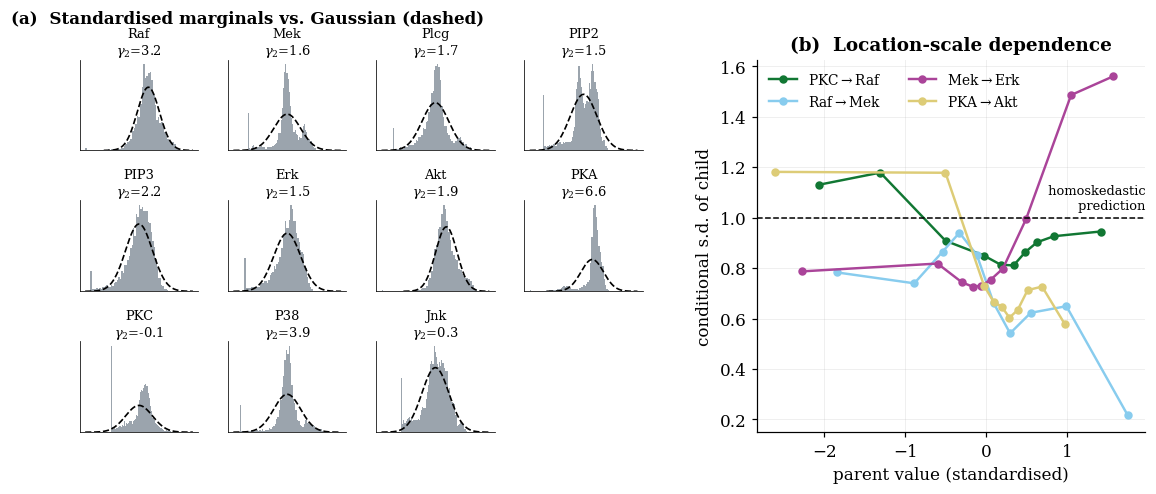

In [3]:
# =====================================================================
# A.2  MOTIVATION FIGURE
# =====================================================================
fig = plt.figure(figsize=(12.5, 4.4))
gs = fig.add_gridspec(1, 2, width_ratios=[1.45, 1.0], wspace=0.24)

# --- left: marginals vs Gaussian ---
gsl = gs[0].subgridspec(3, 4, hspace=0.55, wspace=0.25)
grid = np.linspace(-4, 4, 200)
gauss = np.exp(-grid**2 / 2) / np.sqrt(2 * np.pi)
for i, p in enumerate(PROTEINS):
    ax = fig.add_subplot(gsl[i // 4, i % 4])
    ax.hist(X_std[i], bins=60, density=True, color=C_DATA, alpha=0.55, lw=0)
    ax.plot(grid, gauss, color="k", lw=1.1, ls="--")
    ax.set_title(f"{p}\n$\\gamma_2$={kurtosis(X_std[i]):.1f}", fontsize=8.5, pad=3)
    ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)
    for s in ax.spines.values(): s.set_linewidth(0.5)
fig.add_subplot(gsl[2, 3]).axis("off")
fig.text(0.075, 0.955, "(a)  Standardised marginals vs. Gaussian (dashed)",
         fontsize=11, fontweight="bold")

# --- right: conditional sd of child given parent ---
axr = fig.add_subplot(gs[1])
for (par, ch), col in zip([("PKC", "Raf"), ("Raf", "Mek"), ("Mek", "Erk"), ("PKA", "Akt")],
                          QUAL):
    xp, xc = X_std[IDX[par]], X_std[IDX[ch]]
    qs = np.quantile(xp, np.linspace(0, 1, 11))
    cen, sd = [], []
    for a, b in zip(qs[:-1], qs[1:]):
        m = (xp >= a) & (xp < b)
        if m.sum() > 30:
            cen.append(xp[m].mean()); sd.append(xc[m].std())
    axr.plot(cen, sd, "o-", color=col, lw=1.6, ms=4.5, label=f"{par}$\\to${ch}")
axr.axhline(1.0, color="k", ls="--", lw=1.0)
axr.text(axr.get_xlim()[1], 1.02, " homoskedastic\n prediction", fontsize=8.5, va="bottom", ha="right")
axr.set_xlabel("parent value (standardised)")
axr.set_ylabel("conditional s.d. of child")
axr.set_title("(b)  Location-scale dependence", fontweight="bold")
axr.legend(fontsize=9, ncol=2)

plt.savefig(f"{FIGDIR}/sachs_nongaussianity.pdf")
plt.show()

## A.3 The LiNGAM post-processing pipeline

Both solvers return a full unmixing matrix $\mathbf{W}_{\text{full}}$ mapping *centred*
observations to estimated shocks, $\hat{\mathbf{e}} = \mathbf{W}_{\text{full}}\,\mathbf{x}_c$.
Under LiNGAM,

$$\mathbf{W}_{\text{full}} = \mathbf{P}\,\mathbf{D}\,(\mathbf{I}-\mathbf{B}),$$

with $\mathbf{P}$ an unknown permutation and $\mathbf{D}$ an unknown diagonal scaling
(the ICA sign/scale ambiguity). Recovery therefore requires three steps, applied
*identically* to both solvers:

1. **Resolve $\mathbf{P}$** — Hungarian assignment **minimising** $\sum_i 1/|W_{ii}|$
   (Shimizu et al. 2006, Alg. A). Maximising $\sum_i|W_{ii}|$ instead admits permutations
   with a near-zero diagonal entry, which the next step then divides by, producing spurious
   coefficients of magnitude $10^1$–$10^2$.
2. **Resolve $\mathbf{D}$** — divide each row by its diagonal entry, then $\mathbf{B}=\mathbf{I}-\mathbf{W}$.
3. **Causal order** — Shimizu Algorithm B: zero the $n(n{+}1)/2$ smallest entries of
   $\mathbf{B}$, test whether the result is permutable to strictly lower triangular, and grow
   the zero set until it is. The order is thus produced *by the algorithm* and can be
   validated against ground truth, unlike a heuristic sort by row mass.

In [4]:
# =====================================================================
# A.3  LiNGAM POST-PROCESSING + METRICS  (shared by both solvers)
# =====================================================================
def w_to_B(W_full):
    """Full unmixing matrix -> estimated adjacency B (B[i, j] = effect of j on i)."""
    d = W_full.shape[0]
    cost = 1.0 / np.maximum(np.abs(W_full), 1e-12)        # Shimizu Alg. A step 2
    r_ind, c_ind = linear_sum_assignment(cost)            # MINIMISE sum 1/|W_ii|
    W_p = np.zeros_like(W_full)
    W_p[c_ind, :] = W_full[r_ind, :]
    W_n = W_p / np.diag(W_p)[:, None]                     # resolve scaling D
    return np.eye(d) - W_n                                 # B = I - W


def _permutable_to_strict_lower(Bz):
    """Return a causal order if Bz is permutable to strictly lower triangular, else None."""
    n = Bz.shape[0]
    remaining, order = list(range(n)), []
    for _ in range(n):
        hit = None
        for node in remaining:                             # a row with no remaining parents
            if not np.any(Bz[node, remaining] != 0):
                hit = node; break
        if hit is None:
            return None
        order.append(hit); remaining.remove(hit)
    return order


def causal_order(B):
    """Shimizu et al. (2006) Algorithm B."""
    n = B.shape[0]
    rank = np.argsort(np.abs(B), axis=None)                # ascending magnitude
    for m in range(n * (n + 1) // 2, n * n + 1):
        Bt = B.copy(); Bt.flat[rank[:m]] = 0.0
        order = _permutable_to_strict_lower(Bt)
        if order is not None:
            return order
    return list(np.argsort(np.abs(B).sum(1)))              # fallback (should not trigger)


def topk_edges(B, k):
    """Binary edge prediction from the k largest |B_ij| (i != j). No tuned threshold."""
    S = np.abs(B).copy(); np.fill_diagonal(S, 0.0)
    P = np.zeros_like(S)
    P.flat[np.argsort(-S, axis=None)[:k]] = 1.0
    return P


def edge_metrics(B, A_true):
    k = int(A_true.sum())
    P = topk_edges(B, k)
    pred = {(i, j) for i, j in zip(*np.where(P == 1))}
    true = {(i, j) for i, j in zip(*np.where(A_true == 1))}
    rev     = {(i, j) for (i, j) in pred if (j, i) in true and (i, j) not in true}
    tp      = pred & true
    extra   = pred - true - rev
    missing = true - {(j, i) for (i, j) in rev} - pred
    prec = len(tp) / max(len(pred), 1)
    rec  = len(tp) / max(len(true), 1)
    f1   = 2 * prec * rec / max(prec + rec, 1e-12)

    off = ~np.eye(A_true.shape[0], dtype=bool)
    S = np.abs(B)[off]
    auc = roc_auc_score(A_true[off].astype(int), S) if A_true[off].sum() > 0 else np.nan
    return dict(precision=prec, recall=rec, f1=f1,
                shd=len(extra) + len(missing) + len(rev), auc=auc,
                reversed_=len(rev))


def order_consistency(order, A_true):
    """Fraction of true edges p->c respecting the estimated order. Chance = 0.5."""
    rank = {n: r for r, n in enumerate(order)}
    ch, pa = np.where(A_true == 1)
    return float(np.mean([rank[p] < rank[c] for c, p in zip(ch, pa)]))


def residual_dependence(S):
    """Mean |Spearman rho| between |s_i| and |s_j|. Ground-truth-free ICA quality metric:
    catches the location-scale dependence that linear decorrelation cannot see."""
    A = np.abs(S)
    vals = [abs(spearmanr(A[i], A[j]).correlation)
            for i, j in itertools.combinations(range(A.shape[0]), 2)]
    return float(np.nanmean(vals))

## A.4 Solvers

**The whitening bug this replaces.** In the previous version the data was whitened in NumPy
*and again* inside `WassersteinICA.whiten()`. After the first whitening the covariance is the
identity, so `eigh` returns an arbitrary orthonormal eigenbasis $\mathbf{E}$; the class then
operated on $\mathbf{E}^\top\mathbf{X}_w$, making the true unmixing
$\mathbf{W}_{\text{est}}\mathbf{E}^\top\mathbf{W}_{\text{white}}$ rather than
$\mathbf{W}_{\text{est}}\mathbf{W}_{\text{white}}$. The recovered $\mathbf{B}$ was off by an
arbitrary rotation. Below, whitening happens **once**, inside the class, and
`model.W_white` is read back out.

We also record the $W_2^2$ objective in stages so convergence can be verified rather than assumed.

In [5]:
# =====================================================================
# A.4  SOLVERS
# =====================================================================
def run_ot_ica(X_centered, seed=SEED, n_restarts=128, defl_iter=200,
               stages=10, iters_per_stage=60, lr=0.05, lr_decay=0.99,
               dither=0.01, batch_size=1024, cost="l2", verbose=False):
    """OT-ICA: deflationary warm start -> symmetric Stiefel refinement.
    Returns (W_full, sources, objective_trace)."""
    set_seed(seed)
    Xt = torch.from_numpy(X_centered).float().to(DEVICE)
    model = WassersteinICA(Xt)
    model.whiten()                                   # the ONLY whitening
    d = X_centered.shape[0]

    # --- Phase 1: deflation with parallel restarts (global warm start) ---
    ws = []
    for _ in range(d):
        prev = torch.stack(ws) if ws else None
        w, _ = model.optimize_wasserstein2(prev_components=prev, max_iter=defl_iter,
                                           n_restarts=n_restarts, dither_sigma=dither,
                                           cost=cost)
        ws.append(w)
    W = torch.stack(ws)

    # --- Phase 2: symmetric Stiefel ascent, run in stages to trace the objective ---
    trace = [model.wasserstein2_analytical(W, cost=cost, dither_sigma=0.01).sum().item()]
    for s in range(stages):
        lr_s = lr * (lr_decay ** (s * iters_per_stage))   # continue the schedule
        W = model.optimize_symmetric(n_components=d, max_iter=iters_per_stage, lr=lr_s,
                                     init_w=W, optimizer="stiefel", batch_size=batch_size,
                                     dither_sigma=dither, cost=cost)
        trace.append(model.wasserstein2_analytical(W, cost=cost, dither_sigma=0.01).sum().item())
        if verbose:
            print(f"    stage {s+1}/{stages}  lr={lr_s:.2e}  W2 = {trace[-1]:.5f}")

    W_full = (W.cpu().numpy() @ model.W_white.cpu().numpy())
    S = W_full @ X_centered
    return W_full, S, np.array(trace)


def run_fast_ica(X_centered, seed=SEED, fun="logcosh", max_iter=2000, tol=1e-6):
    """Baseline: FastICA (the standard ICA-LiNGAM solver)."""
    set_seed(seed)
    ica = FastICA(n_components=X_centered.shape[0], whiten="unit-variance",
                  fun=fun, max_iter=max_iter, tol=tol, random_state=seed)
    ica.fit(X_centered.T)
    W_full = ica.components_               # maps centred X to sources
    return W_full, W_full @ X_centered

## A.5 Single reference run and convergence check

Before the multi-seed study, one run at the global seed, with the $W_2^2$ objective trace.
A flat tail confirms the Stiefel schedule has settled; a still-rising curve means
`stages` or `lr` needs increasing.

    stage 1/10  lr=5.00e-02  W2 = 1.79357
    stage 2/10  lr=2.74e-02  W2 = 1.80804
    stage 3/10  lr=1.50e-02  W2 = 1.81723
    stage 4/10  lr=8.19e-03  W2 = 1.82111
    stage 5/10  lr=4.48e-03  W2 = 1.82436
    stage 6/10  lr=2.45e-03  W2 = 1.82601
    stage 7/10  lr=1.34e-03  W2 = 1.82766
    stage 8/10  lr=7.34e-04  W2 = 1.82845
    stage 9/10  lr=4.02e-04  W2 = 1.82769
    stage 10/10  lr=2.20e-04  W2 = 1.82805

--- reference run (seed = 42) ---
OT-ICA    F1=0.353  SHD=20  AUC=0.696  order=0.471  resid.dep=0.0576
          order: Raf -> PIP2 -> Plcg -> PIP3 -> PKA -> Akt -> Erk -> P38 -> Mek -> PKC -> Jnk
FastICA   F1=0.353  SHD=20  AUC=0.605  order=0.412  resid.dep=0.0566
          order: Raf -> Plcg -> PIP2 -> PIP3 -> Akt -> Erk -> PKA -> P38 -> Mek -> PKC -> Jnk


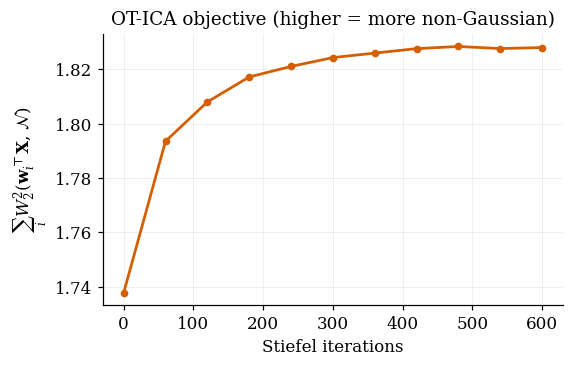

In [6]:
# =====================================================================
# A.5  REFERENCE RUN
# =====================================================================
set_seed(SEED)
Xc = X_std - X_std.mean(1, keepdims=True)

W_ot, S_ot, trace = run_ot_ica(Xc, seed=SEED, verbose=True)
W_fi, S_fi        = run_fast_ica(Xc, seed=SEED)

B_ot, B_fi = w_to_B(W_ot), w_to_B(W_fi)
ord_ot, ord_fi = causal_order(B_ot), causal_order(B_fi)

print("\n--- reference run (seed = %d) ---" % SEED)
for tag, B, od, S in [("OT-ICA", B_ot, ord_ot, S_ot), ("FastICA", B_fi, ord_fi, S_fi)]:
    m = edge_metrics(B, A_TRUE)
    print(f"{tag:8s}  F1={m['f1']:.3f}  SHD={m['shd']:2d}  AUC={m['auc']:.3f}  "
          f"order={order_consistency(od, A_TRUE):.3f}  resid.dep={residual_dependence(S):.4f}")
    print(f"{'':8s}  order: {' -> '.join(PROTEINS[i] for i in od)}")

# convergence trace
fig, ax = plt.subplots(figsize=(5.4, 3.2))
ax.plot(np.arange(len(trace)) * 60, trace, "o-", color=C_OT, lw=1.8, ms=4)
ax.set_xlabel("Stiefel iterations"); ax.set_ylabel("$\\sum_i W_2^2(\\mathbf{w}_i^\\top \\mathbf{X},\\, \\mathcal{N})$")
ax.set_title("OT-ICA objective (higher = more non-Gaussian)")
plt.savefig(f"{FIGDIR}/ot_ica_convergence.pdf"); plt.show()

## A.6 Multi-seed comparison on real Sachs data

FastICA's fixed-point iteration is sensitive to its random initialisation, and OT-ICA's
deflation phase uses random restarts. A single run of either is not evidence. We repeat
both over 10 seeds and report mean ± s.d. **Variance itself is a result**: a solver whose
recovered network changes across restarts is not usable for scientific discovery.

In [7]:
# =====================================================================
# A.6  MULTI-SEED STUDY (real data)
# =====================================================================
N_SEEDS = 10
SEEDS = [SEED + i for i in range(N_SEEDS)]

rows, B_store = [], {"OT-ICA": [], "FastICA": []}
for s in SEEDS:
    for tag, fn in [("OT-ICA",  lambda: run_ot_ica(Xc, seed=s, n_restarts=96)[:2]),
                    ("FastICA", lambda: run_fast_ica(Xc, seed=s))]:
        W, S = fn()
        B = w_to_B(W)
        m = edge_metrics(B, A_TRUE)
        m.update(method=tag, seed=s,
                 order=order_consistency(causal_order(B), A_TRUE),
                 resid_dep=residual_dependence(S))
        rows.append(m); B_store[tag].append(B)
    print(f"seed {s} done")

res = pd.DataFrame(rows)
summary = (res.groupby("method")[["f1", "precision", "recall", "shd", "auc", "order", "resid_dep"]]
              .agg(["mean", "std"]).round(3))
print("\n=== Sachs (real data), mean +/- s.d. over %d seeds ===" % N_SEEDS)
print(summary.to_string())

# run-to-run instability of the recovered network (Jaccard between top-k edge sets)
def jaccard_stability(Bs, k):
    sets = [frozenset(map(tuple, np.argwhere(topk_edges(B, k) == 1))) for B in Bs]
    return float(np.mean([len(a & b) / len(a | b) for a, b in itertools.combinations(sets, 2)]))

print("\nEdge-set stability across seeds (Jaccard, higher = more reproducible):")
for tag in B_store:
    print(f"  {tag:8s} {jaccard_stability(B_store[tag], K_TRUE):.3f}")

seed 42 done
seed 43 done
seed 44 done
seed 45 done
seed 46 done
seed 47 done
seed 48 done
seed 49 done
seed 50 done
seed 51 done

=== Sachs (real data), mean +/- s.d. over 10 seeds ===
            f1      precision      recall        shd         auc         order      resid_dep     
          mean  std      mean  std   mean  std  mean  std   mean    std   mean  std      mean  std
method                                                                                            
FastICA  0.353  0.0     0.353  0.0  0.353  0.0  20.0  0.0  0.607  0.001  0.412  0.0     0.057  0.0
OT-ICA   0.353  0.0     0.353  0.0  0.353  0.0  20.0  0.0  0.694  0.002  0.471  0.0     0.058  0.0

Edge-set stability across seeds (Jaccard, higher = more reproducible):
  OT-ICA   0.941
  FastICA  1.000


In [8]:
# =====================================================================
# A.6b  BASELINES (context for F1 and SHD)
# =====================================================================
rng = np.random.default_rng(SEED)
off_cells = [(i, j) for i in range(D) for j in range(D) if i != j]

rand_f1, rand_shd = [], []
for _ in range(2000):
    P = np.zeros((D, D))
    for t in rng.choice(len(off_cells), K_TRUE, replace=False):
        P[off_cells[t]] = 1
    tp  = int(((P == 1) & (A_TRUE == 1)).sum())
    rev = int(((P == 1) & (A_TRUE.T == 1) & (A_TRUE == 0)).sum())
    rand_f1.append(tp / K_TRUE)
    rand_shd.append((K_TRUE - tp - rev) * 2 + rev)

print(f"Random top-{K_TRUE} graph : F1 = {np.mean(rand_f1):.3f} +/- {np.std(rand_f1):.3f}, "
      f"SHD = {np.mean(rand_shd):.1f}")
print(f"Empty graph              : F1 = 0.000, SHD = {K_TRUE}")
print(f"Chance AUC               : 0.500   |   chance order consistency: 0.500")

Random top-17 graph : F1 = 0.152 +/- 0.080, SHD = 26.2
Empty graph              : F1 = 0.000, SHD = 17
Chance AUC               : 0.500   |   chance order consistency: 0.500


In [9]:
# =====================================================================
# A.6c  PAIRED BOOTSTRAP ON THE AUC GAP
# =====================================================================
def paired_auc_bootstrap(B1, B2, A_true, n_boot=4000, seed=SEED):
    """Bootstrap over off-diagonal cells: AUC(B1) - AUC(B2)."""
    off = ~np.eye(A_true.shape[0], dtype=bool)
    y, s1, s2 = A_true[off].astype(int), np.abs(B1)[off], np.abs(B2)[off]
    rng, deltas = np.random.default_rng(seed), []
    for _ in range(n_boot):
        idx = rng.integers(0, len(y), len(y))
        if 0 < y[idx].sum() < len(y):
            deltas.append(roc_auc_score(y[idx], s1[idx]) - roc_auc_score(y[idx], s2[idx]))
    d = np.asarray(deltas)
    return d.mean(), np.percentile(d, [2.5, 97.5]), float((d <= 0).mean())

def median_run(tag):
    sub = res[res.method == tag].reset_index(drop=True)
    return B_store[tag][int((sub.f1 - sub.f1.median()).abs().idxmin())]

B_ot_m, B_fi_m = median_run("OT-ICA"), median_run("FastICA")

m, ci, p = paired_auc_bootstrap(B_ot_m, B_fi_m, A_TRUE)
print(f"AUC(OT-ICA) - AUC(FastICA) = {m:+.3f}   95% CI [{ci[0]:+.3f}, {ci[1]:+.3f}]   "
      f"P(delta <= 0) = {p:.3f}")

AUC(OT-ICA) - AUC(FastICA) = +0.091   95% CI [+0.018, +0.182]   P(delta <= 0) = 0.003


In [ ]:
# =====================================================================
# A.6d  SIGN TEST: OT-ICA vs FastICA, paired by seed (Table 9, real Sachs data)
#      `res` already has an explicit `seed` column. This complements the
#      paired-bootstrap AUC test above (cell A.6c) with the other headline
#      metrics; f1/shd are expected to show n_pairs=0 (exact ties) since the
#      solvers select the same top-17 edge set on every seed here.
# =====================================================================
from scipy.stats import binomtest

def sign_test_paired(df, metric, ref="OT-ICA", other="FastICA",
                     lower_is_better=True, id_col="seed", method_col="method"):
    piv = df.pivot(index=id_col, columns=method_col, values=metric)
    a, b = piv[ref], piv[other]
    mask = a.notna() & b.notna() & (a != b)
    n = int(mask.sum())
    wins = int((a[mask] < b[mask]).sum()) if lower_is_better else int((a[mask] > b[mask]).sum())
    p = binomtest(wins, n, 0.5, alternative="two-sided").pvalue if n > 0 else np.nan
    return {"metric": metric, "n_pairs": n, f"wins_{ref}": wins,
            f"losses_{ref}": n - wins, "p_value": p}

sign_sachs = pd.DataFrame([
    sign_test_paired(res, "f1", lower_is_better=False),
    sign_test_paired(res, "shd", lower_is_better=True),
    sign_test_paired(res, "order", lower_is_better=False),
    sign_test_paired(res, "resid_dep", lower_is_better=True),
])
print("Sign test, OT-ICA vs FastICA, paired by seed (real Sachs data):")
print(sign_sachs.to_string(index=False))
print("\nn_pairs=0 means every pair was tied on that metric (expected for f1/shd, "
      "given the two solvers pick the same top-17 edges on every seed here); the "
      "existing paired-bootstrap AUC test above is the informative test for this "
      "table, since AUC is where the solvers actually differ.")


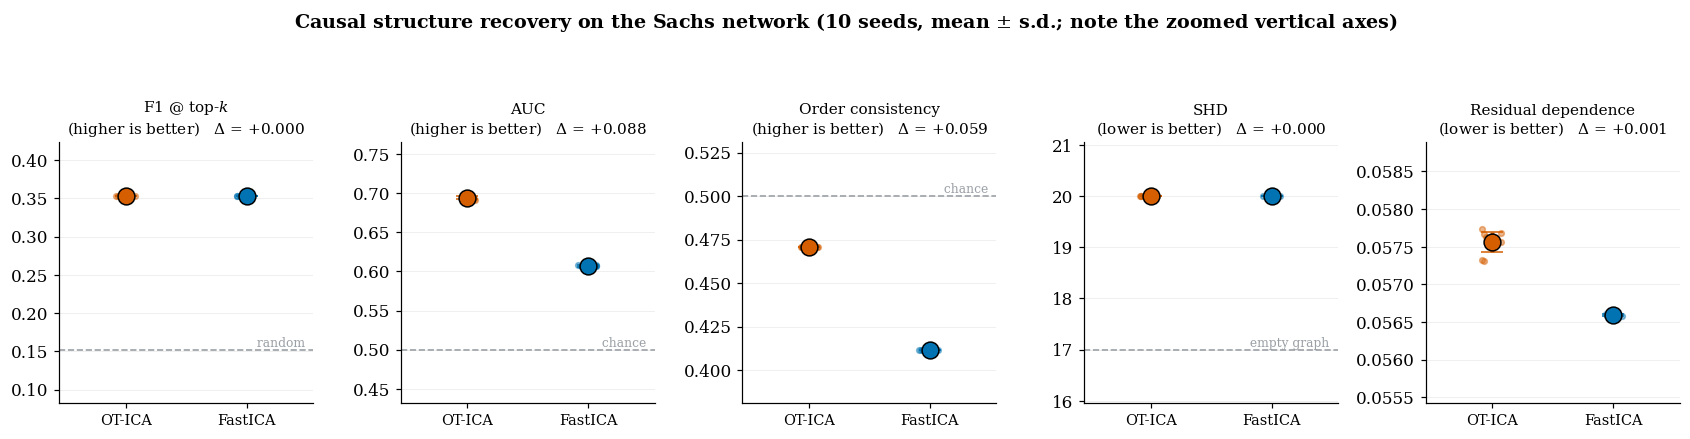

In [10]:
# =====================================================================
# A.7  RESULTS FIGURE (zoomed axes + reference lines)
# =====================================================================
metrics = [("f1", "F1 @ top-$k$", "higher", np.mean(rand_f1)),
           ("auc", "AUC", "higher", 0.5),
           ("order", "Order consistency", "higher", 0.5),
           ("shd", "SHD", "lower", float(K_TRUE)),
           ("resid_dep", "Residual dependence", "lower", None)]

fig, axes = plt.subplots(1, len(metrics), figsize=(15.5, 3.7))
for ax, (key, label, direction, ref) in zip(axes, metrics):
    vals = {t: res.loc[res.method == t, key].values for t in ["OT-ICA", "FastICA"]}
    for x, tag in enumerate(["OT-ICA", "FastICA"]):
        v = vals[tag]
        ax.errorbar(x, v.mean(), yerr=v.std(), fmt="o", ms=11, lw=2.2, capsize=7,
                    color=PALETTE[tag], mec="black", mew=1.0, zorder=4)
        ax.scatter(np.full(len(v), x) + np.random.uniform(-.09, .09, len(v)), v,
                   s=14, color=PALETTE[tag], alpha=0.45, zorder=3)

    pool = np.concatenate(list(vals.values()) + ([[ref]] if ref is not None else []))
    lo, hi = pool.min(), pool.max()
    pad = max((hi - lo) * 0.35, (abs(hi) + 1e-9) * 0.02)
    ax.set_ylim(lo - pad, hi + pad)

    if ref is not None:
        ax.axhline(ref, color=C_GREY, ls="--", lw=1.1, zorder=1)
        tag_txt = {"f1": "random", "auc": "chance",
                   "order": "chance", "shd": "empty graph"}[key]
        ax.text(1.48, ref, f" {tag_txt}", fontsize=8, color=C_GREY,
                va="bottom", ha="right")

    d = vals["OT-ICA"].mean() - vals["FastICA"].mean()
    ax.set_xlim(-0.55, 1.55)
    ax.set_xticks([0, 1]); ax.set_xticklabels(["OT-ICA", "FastICA"], fontsize=9.5)
    ax.set_title(f"{label}\n({direction} is better)   $\\Delta$ = {d:+.3f}", fontsize=10)
    ax.grid(axis="x", visible=False)

fig.suptitle("Causal structure recovery on the Sachs network (%d seeds, mean $\\pm$ s.d.; "
             "note the zoomed vertical axes)" % N_SEEDS,
             y=1.07, fontsize=12.5, fontweight="bold")
plt.tight_layout(); plt.savefig(f"{FIGDIR}/sachs_metrics.pdf"); plt.show()

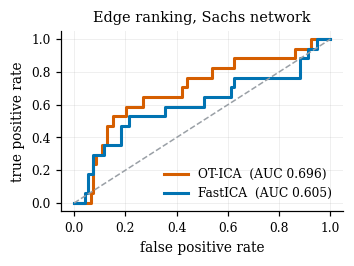

In [11]:
# =====================================================================
# A.7b  SINGLE-COLUMN ROC FIGURE (edge ranking)
# =====================================================================
from sklearn.metrics import roc_curve

off = ~np.eye(D, dtype=bool)
y = A_TRUE[off].astype(int)

fig, ax = plt.subplots(figsize=(3.35, 2.55))
for tag, B in [("OT-ICA", B_ot_m), ("FastICA", B_fi_m)]:
    a = res.loc[res.method == tag, "auc"]
    fpr, tpr, _ = roc_curve(y, np.abs(B)[off])
    auc_med = roc_auc_score(y, np.abs(B)[off])
    ax.plot(fpr, tpr, lw=2.0, color=PALETTE[tag],
            label=f"{tag}  (AUC {auc_med:.3f})")
ax.plot([0, 1], [0, 1], ls="--", lw=1.0, color=C_GREY)
#ax.text(0.97, 0.06, r"$\Delta$AUC $= +0.091$" "\n" r"95% CI $[+0.02, +0.18]$",
#        transform=ax.transAxes, ha="right", va="center", fontsize=7.5, color="0.3")
ax.set_xlabel("false positive rate", fontsize=9)
ax.set_ylabel("true positive rate", fontsize=9)
ax.tick_params(labelsize=8)
ax.legend(fontsize=8, loc="lower right")
ax.set_title("Edge ranking, Sachs network", fontsize=9.5)
plt.tight_layout(); plt.savefig(f"figs/sachs_roc.pdf"); plt.show()

## A.8 Improved topologically sorted adjacency heatmap

Three changes from the previous version:

1. **Robust colour scale** (98th percentile of $|B|$, symmetric about zero) so a single
   artefact cannot wash out the entire matrix.
2. **Ground truth is overlaid** — black outlines mark the 17 consensus edges. The reader can
   see immediately whether recovered mass lands on real edges.
3. **A quantitative caption number** replaces "a dominant lower-triangular structure emerges":
   the fraction of total $|B|$ mass below the diagonal, plus the fraction of *true* edges
   respecting the estimated order. Both are stated in the figure.

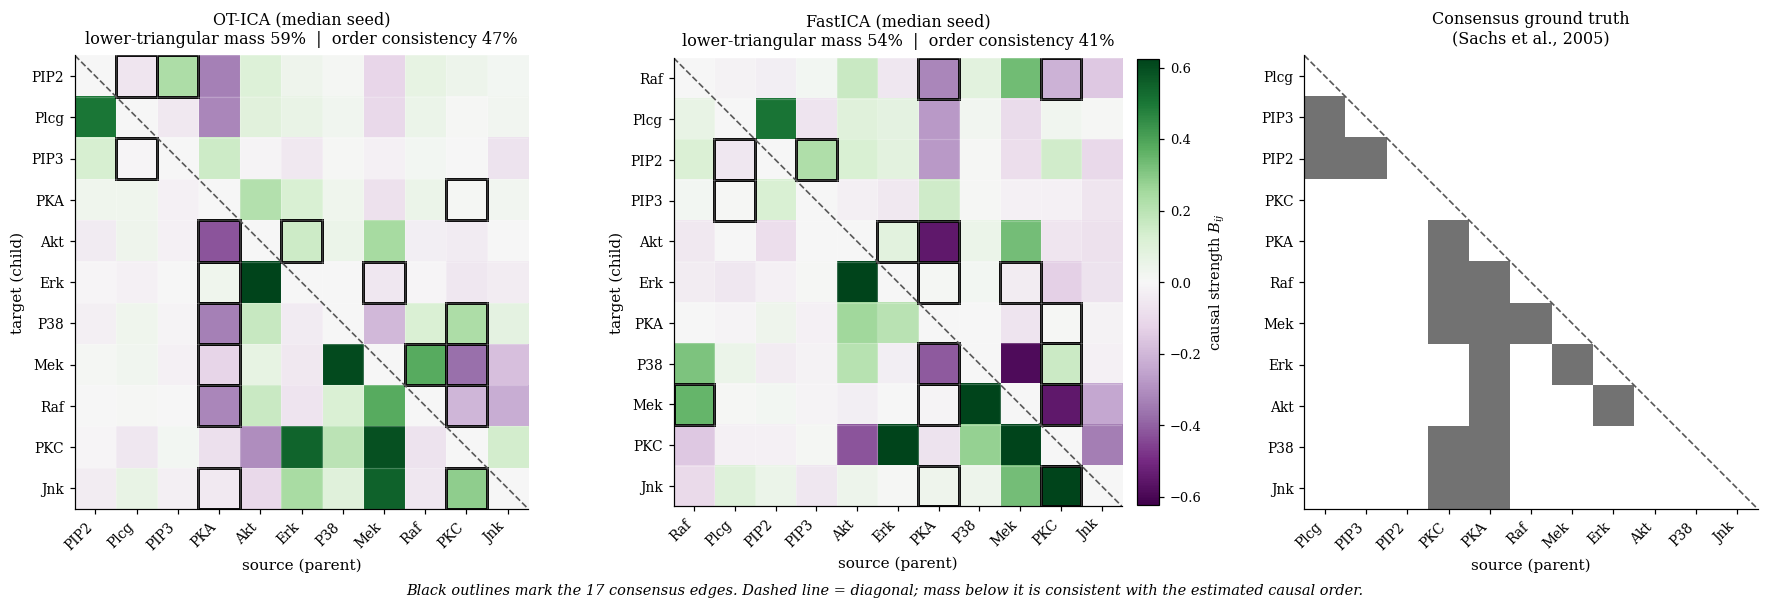

In [12]:
# =====================================================================
# A.8  TOPOLOGICALLY SORTED HEATMAP  (OT-ICA | FastICA | ground truth)
# =====================================================================
def plot_sorted_B(B, order, A_true, names, ax, title, show_cbar=False, ref_scale=None):
    d = B.shape[0]
    Bo = B[np.ix_(order, order)]
    Ao = A_true[np.ix_(order, order)]
    lab = [names[i] for i in order]

    vmax = ref_scale if ref_scale is not None else np.percentile(np.abs(Bo), 98)
    vmax = max(vmax, 1e-6)
    im = ax.imshow(np.clip(Bo, -vmax, vmax), cmap=CMAP_B, vmin=-vmax, vmax=vmax)

    tril = np.tril(np.abs(Bo), -1).sum()
    mass = tril / max(np.abs(Bo).sum() - np.abs(np.diag(Bo)).sum(), 1e-12)
    fwd  = order_consistency(order, A_true)

    for (i, j) in zip(*np.where(Ao == 1)):          # ground-truth edges
        ax.add_patch(plt.Rectangle((j - .5, i - .5), 1, 1, fill=False,
                                   edgecolor="black", lw=1.9))
    ax.plot([-.5, d - .5], [-.5, d - .5], color="0.35", lw=1.1, ls="--")

    ax.set_xticks(range(d)); ax.set_xticklabels(lab, rotation=45, ha="right", fontsize=9)
    ax.set_yticks(range(d)); ax.set_yticklabels(lab, fontsize=9)
    ax.set_xlabel("source (parent)", fontsize=10)
    ax.set_ylabel("target (child)", fontsize=10)
    ax.set_title(f"{title}\nlower-triangular mass {mass:.0%}  |  order consistency {fwd:.0%}",
                 fontsize=10.5, pad=8)
    ax.grid(False)
    ax.set_xticks(np.arange(-.5, d, 1), minor=True)
    ax.set_yticks(np.arange(-.5, d, 1), minor=True)
    ax.tick_params(which="minor", length=0)
    ax.grid(which="minor", color="white", lw=0.8)
    if show_cbar:
        cb = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.03)
        cb.set_label("causal strength $B_{ij}$", fontsize=9.5)
        cb.ax.tick_params(labelsize=8.5)
    return im

# median-seed representatives (avoids cherry-picking the best run)
def median_run(tag):
    sub = res[res.method == tag].reset_index(drop=True)
    return B_store[tag][int((sub.f1 - sub.f1.median()).abs().idxmin())]

B_ot_m, B_fi_m = median_run("OT-ICA"), median_run("FastICA")
scale = np.percentile(np.abs(np.concatenate([B_ot_m.ravel(), B_fi_m.ravel()])), 98)

fig, axes = plt.subplots(1, 3, figsize=(16.5, 5.2))
plot_sorted_B(B_ot_m, causal_order(B_ot_m), A_TRUE, PROTEINS, axes[0],
              "OT-ICA (median seed)", ref_scale=scale)
plot_sorted_B(B_fi_m, causal_order(B_fi_m), A_TRUE, PROTEINS, axes[1],
              "FastICA (median seed)", show_cbar=True, ref_scale=scale)

# ground-truth reference panel in its own topological order
gt_order = _permutable_to_strict_lower(A_TRUE) or list(range(D))
axes[2].imshow(A_TRUE[np.ix_(gt_order, gt_order)], cmap="Greys", vmin=0, vmax=1.6)
axes[2].set_xticks(range(D)); axes[2].set_xticklabels([PROTEINS[i] for i in gt_order],
                                                      rotation=45, ha="right", fontsize=9)
axes[2].set_yticks(range(D)); axes[2].set_yticklabels([PROTEINS[i] for i in gt_order], fontsize=9)
axes[2].plot([-.5, D - .5], [-.5, D - .5], color="0.35", lw=1.1, ls="--")
axes[2].set_title("Consensus ground truth\n(Sachs et al., 2005)", fontsize=10.5, pad=8)
axes[2].set_xlabel("source (parent)", fontsize=10); axes[2].grid(False)

fig.text(0.5, -0.03, "Black outlines mark the 17 consensus edges. Dashed line = diagonal; "
                     "mass below it is consistent with the estimated causal order.",
         ha="center", fontsize=9.5, style="italic")
plt.tight_layout()
plt.savefig(f"{FIGDIR}/estimated_causal_sorted_mtx_sachs.pdf")
plt.show()

## A.9 Layered DAG rendering

A `spring_layout` places nodes by a force simulation that ignores causal direction, which is
why the previous graph was unreadable. Here nodes are assigned to **layers by longest path**
in the estimated DAG, ordered within each layer by a barycentre sweep to reduce crossings —
the same principle as Graphviz's `dot` (Sugiyama layout), implemented directly in Matplotlib
so no Graphviz dependency is needed.

Edges are coloured by sign, widths scale with $|B_{ij}|$, and **solid = recovered true edge,
dashed grey = false positive**, so the figure carries the evaluation rather than just the output.

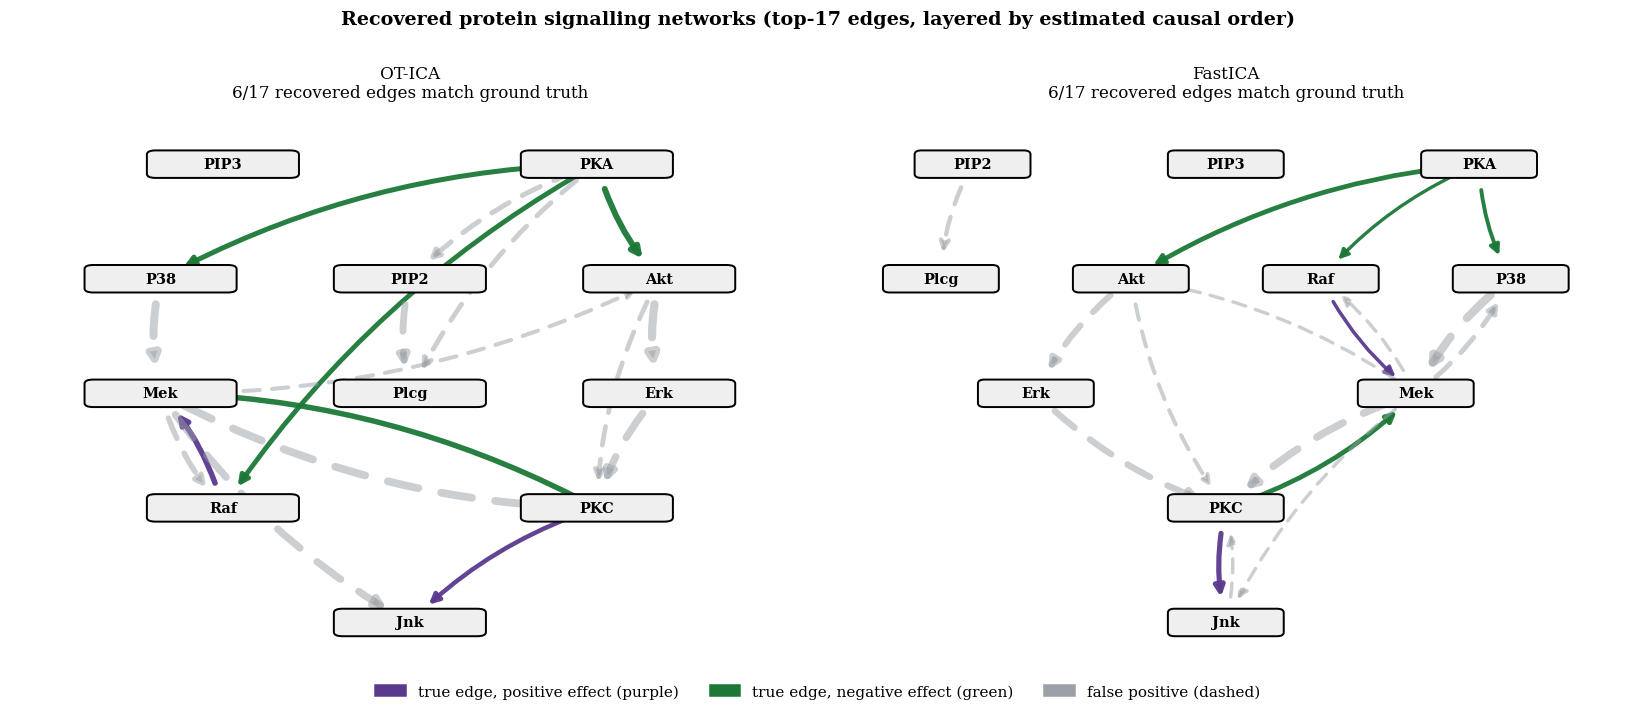

In [13]:
# =====================================================================
# A.9  LAYERED (SUGIYAMA-STYLE) DAG RENDERER
# =====================================================================
def layered_positions(adj, order, sweeps=12):
    d = adj.shape[0]
    layer = np.zeros(d, dtype=int)
    for node in order:                                  # parents first
        par = np.where(adj[node] != 0)[0]
        if len(par):
            layer[node] = max(layer[p] for p in par) + 1
    groups = {}
    for i, l in enumerate(layer):
        groups.setdefault(int(l), []).append(i)

    xr = {n: k for l in groups for k, n in enumerate(groups[l])}
    for s in range(sweeps):                             # barycentre crossing reduction
        for l in sorted(groups, reverse=bool(s % 2)):
            nodes = groups[l]
            bary = []
            for n in nodes:
                nb = [m for m in range(d)
                      if (adj[n, m] or adj[m, n]) and layer[m] != l]
                bary.append(np.mean([xr[m] for m in nb]) if nb else xr[n])
            nodes = [nodes[i] for i in np.argsort(bary)]
            groups[l] = nodes
            for k, n in enumerate(nodes):
                xr[n] = k
    W = max(len(v) for v in groups.values())
    return {n: (((k + .5) / len(groups[l])) * W, -l * 1.0)
            for l in groups for k, n in enumerate(groups[l])}, layer


def draw_layered_dag(B, names, A_true, ax, title, k=None, max_lw=4.5):
    d = B.shape[0]
    k = k or int(A_true.sum())
    P = topk_edges(B, k)
    order = causal_order(B)
    pos, layer = layered_positions(P, order)
    mx = max(np.abs(B[P == 1]).max(), 1e-9)

    for (i, j) in zip(*np.where(P == 1)):               # j -> i
        x0, y0 = pos[j]; x1, y1 = pos[i]
        tp = A_true[i, j] == 1
        w  = 0.9 + max_lw * abs(B[i, j]) / mx
        col = (C_POS if B[i, j] > 0 else C_NEG) if tp else C_GREY
        rad = 0.12 if layer[i] != layer[j] else 0.32
        ax.add_patch(FancyArrowPatch((x0, y0), (x1, y1),
                     connectionstyle=f"arc3,rad={rad}",
                     arrowstyle="-|>", mutation_scale=13,
                     lw=w, color=col, alpha=0.95 if tp else 0.5,
                     linestyle="-" if tp else (0, (4, 3)),
                     shrinkA=17, shrinkB=17, zorder=1))

    for n, (x, y) in pos.items():
        ax.add_patch(FancyBboxPatch((x - .27, y - .085), .54, .17,
                     boxstyle="round,pad=0.035", linewidth=1.3,
                     facecolor="#EFEFEF", edgecolor="black", zorder=2))
        ax.text(x, y, names[n], ha="center", va="center",
                fontsize=9.5, fontweight="bold", zorder=3)

    tp_n = int(((P == 1) & (A_true == 1)).sum())
    ax.set_title(f"{title}\n{tp_n}/{k} recovered edges match ground truth",
                 fontsize=11, pad=10)
    xs = [p[0] for p in pos.values()]; ys = [p[1] for p in pos.values()]
    ax.set_xlim(min(xs) - .6, max(xs) + .6); ax.set_ylim(min(ys) - .45, max(ys) + .45)
    ax.axis("off")


fig, axes = plt.subplots(1, 2, figsize=(15, 6.2))
draw_layered_dag(B_ot_m, PROTEINS, A_TRUE, axes[0], "OT-ICA")
draw_layered_dag(B_fi_m, PROTEINS, A_TRUE, axes[1], "FastICA")
fig.legend(handles=[
    mpatches.Patch(color=C_POS,  label="true edge, positive effect (purple)"),
    mpatches.Patch(color=C_NEG,  label="true edge, negative effect (green)"),
    mpatches.Patch(color=C_GREY, label="false positive (dashed)"),
], loc="lower center", ncol=3, fontsize=10, bbox_to_anchor=(0.5, -0.03))
fig.suptitle("Recovered protein signalling networks (top-%d edges, layered by estimated causal order)"
             % K_TRUE, fontsize=12.5, fontweight="bold", y=1.0)
plt.tight_layout(); plt.savefig(f"{FIGDIR}/sachs_dag_comparison.pdf"); plt.show()

# Part B — Semi-synthetic benchmark on the true Sachs DAG

Real Sachs is a *hard* benchmark: the mechanisms are nonlinear and the pooled data mixes
interventional regimes, so **both** linear solvers score low and a difference between them may
sit inside the noise. It is therefore weak evidence on its own.

Part B fixes the graph to the true 17-edge Sachs DAG, draws linear coefficients, and
simulates data under three noise regimes:

| Regime | Description | LiNGAM assumptions |
|---|---|---|
| `laplace` | i.i.d. Laplace shocks | satisfied |
| `mixture` | continuous + discrete mixture (as in Ch. 4 of the thesis) | satisfied |
| `loc_scale` | child variance scales with $|{\rm parent}|$ | **violated** (misspecified) |

This isolates the solver's contribution with an exact ground truth, and directly connects the
application chapter to the synthetic results at $d = 10, 20, 30$ earlier in the thesis.

**Framing note.** In `loc_scale` the *model* is misspecified, not merely the solver. The
defensible claim is that OT-ICA degrades more gracefully under misspecification — not that it
restores identifiability. State it that way.

In [14]:
# =====================================================================
# B.1  SEMI-SYNTHETIC DATA GENERATOR (true Sachs DAG)
# =====================================================================
def simulate_sachs_lingam(n=2000, regime="laplace", seed=SEED, w_lo=0.4, w_hi=1.0):
    rng = np.random.default_rng(seed)
    order = _permutable_to_strict_lower(A_TRUE)
    B = np.zeros((D, D))
    for c, p in zip(*np.where(A_TRUE == 1)):
        B[c, p] = rng.uniform(w_lo, w_hi) * rng.choice([-1, 1])

    if regime == "laplace":
        E = rng.laplace(0, 1, (D, n))
    elif regime == "mixture":
        E = np.empty((D, n))
        for i in range(D):
            r = i % 3
            if   r == 0: E[i] = rng.laplace(0, 1, n)
            elif r == 1: E[i] = rng.uniform(-np.sqrt(3), np.sqrt(3), n)
            else:        E[i] = rng.choice([-1.0, 1.0], n) + 0.3 * rng.standard_normal(n)
    elif regime == "loc_scale":
        E = rng.laplace(0, 1, (D, n))
    else:
        raise ValueError(regime)

    Z = np.zeros((D, n))
    for node in order:
        par = np.where(B[node] != 0)[0]
        m = B[node, par] @ Z[par] if len(par) else np.zeros(n)
        if regime == "loc_scale" and len(par):
            Z[node] = m + (1.0 + 1.2 * np.abs(Z[par]).mean(0)) * E[node]
        else:
            Z[node] = m + E[node]
    Z = (Z - Z.mean(1, keepdims=True)) / Z.std(1, keepdims=True)
    return Z, B

In [15]:
# =====================================================================
# B.2  BENCHMARK SWEEP
# =====================================================================
REGIMES  = ["laplace", "mixture", "loc_scale"]
N_SYN    = 2000
SYN_SEEDS = [SEED + i for i in range(10)]

syn_rows = []
for regime in REGIMES:
    for s in SYN_SEEDS:
        Z, _ = simulate_sachs_lingam(n=N_SYN, regime=regime, seed=s)
        Zc = Z - Z.mean(1, keepdims=True)
        for tag, fn in [("OT-ICA",  lambda: run_ot_ica(Zc, seed=s, n_restarts=96,
                                                       stages=8, batch_size=512)[:2]),
                        ("FastICA", lambda: run_fast_ica(Zc, seed=s))]:
            W, S = fn()
            B = w_to_B(W)
            m = edge_metrics(B, A_TRUE)
            m.update(method=tag, regime=regime, seed=s,
                     order=order_consistency(causal_order(B), A_TRUE),
                     resid_dep=residual_dependence(S))
            syn_rows.append(m)
    print(f"regime '{regime}' done")

syn = pd.DataFrame(syn_rows)
print("\n=== Semi-synthetic Sachs DAG, mean +/- s.d. over %d seeds ===" % len(SYN_SEEDS))
print(syn.groupby(["regime", "method"])[["f1", "shd", "auc", "order", "resid_dep"]]
         .agg(["mean", "std"]).round(3).to_string())

regime 'laplace' done
regime 'mixture' done
regime 'loc_scale' done

=== Semi-synthetic Sachs DAG, mean +/- s.d. over 10 seeds ===
                      f1          shd           auc         order        resid_dep       
                    mean    std  mean    std   mean    std   mean    std      mean    std
regime    method                                                                         
laplace   FastICA  1.000  0.000   0.0  0.000  1.000  0.000  1.000  0.000     0.018  0.002
          OT-ICA   0.994  0.019   0.2  0.632  1.000  0.000  1.000  0.000     0.019  0.002
loc_scale FastICA  0.506  0.069  13.1  1.663  0.875  0.022  0.465  0.085     0.142  0.005
          OT-ICA   0.471  0.062  14.6  2.366  0.863  0.038  0.512  0.130     0.148  0.005
mixture   FastICA  1.000  0.000   0.0  0.000  1.000  0.000  1.000  0.000     0.018  0.003
          OT-ICA   1.000  0.000   0.0  0.000  1.000  0.000  1.000  0.000     0.018  0.003


In [ ]:
# =====================================================================
# B.2b  SIGN TEST: OT-ICA vs FastICA, paired by seed, per regime (Table 10)
#      `syn` already has explicit `regime`/`seed`/`method` columns. Reuses
#      `sign_test_paired` defined in the real-data sign-test cell above.
# =====================================================================
sign_syn_rows = []
for regime in REGIMES:
    sub = syn[syn.regime == regime]
    for metric, lower in [("f1", False), ("shd", True), ("order", False),
                          ("resid_dep", True)]:
        r = sign_test_paired(sub, metric, lower_is_better=lower)
        r["regime"] = regime
        sign_syn_rows.append(r)

sign_syn = pd.DataFrame(sign_syn_rows)[["regime", "metric", "n_pairs",
                                        "wins_OT-ICA", "losses_OT-ICA", "p_value"]]
print("Sign test, OT-ICA vs FastICA, paired by seed, semi-synthetic Sachs DAG:")
print(sign_syn.to_string(index=False))
print("\nAs in the main text: both solvers saturate under 'laplace' and 'mixture' "
      "(expect many n_pairs=0 ties), and degrade together under 'loc_scale' "
      "misspecification -- the location-scale regime is where a real, non-trivial "
      "sign test is most informative, since that's where the two solvers' F1/SHD "
      "actually spread out across seeds.")


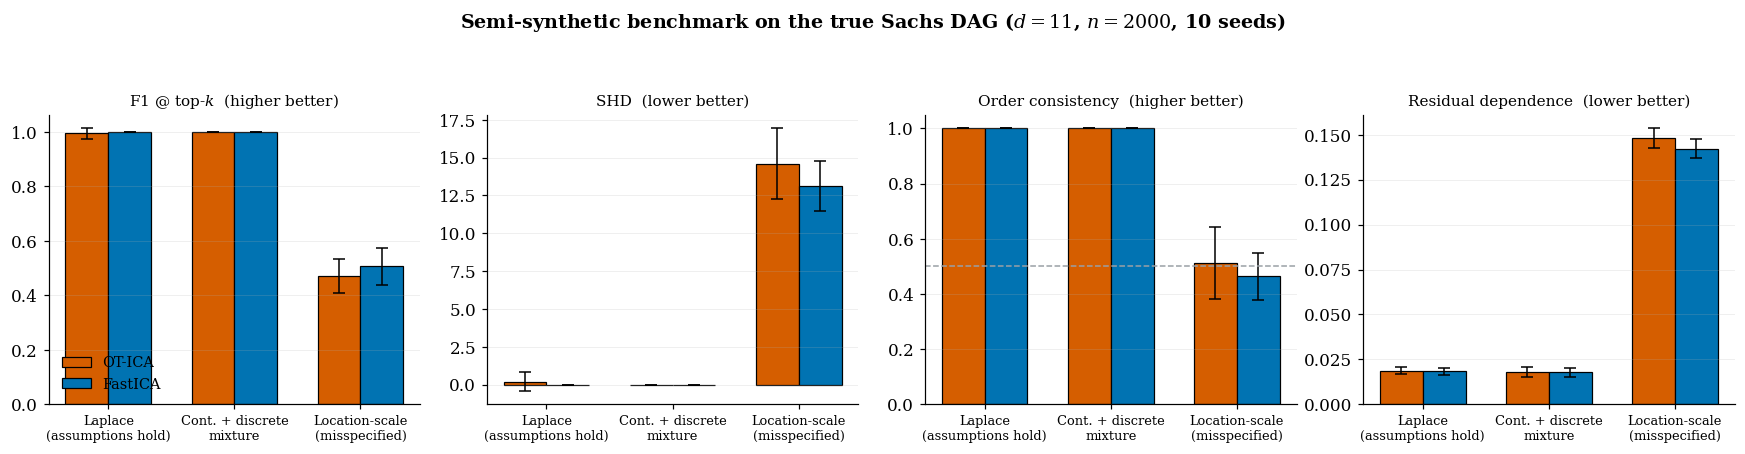

\begin{table}
\caption{Semi-synthetic Sachs benchmark.}
\label{tab:sachs_synth}
\begin{tabular}{llrrrrrrrr}
\toprule
 &  & \multicolumn{2}{r}{f1} & \multicolumn{2}{r}{shd} & \multicolumn{2}{r}{auc} & \multicolumn{2}{r}{order} \\
 &  & mean & std & mean & std & mean & std & mean & std \\
regime & method &  &  &  &  &  &  &  &  \\
\midrule
\multirow[t]{2}{*}{laplace} & FastICA & 1.000000 & 0.000000 & 0.000000 & 0.000000 & 1.000000 & 0.000000 & 1.000000 & 0.000000 \\
 & OT-ICA & 0.994000 & 0.019000 & 0.200000 & 0.632000 & 1.000000 & 0.000000 & 1.000000 & 0.000000 \\
\cline{1-10}
\multirow[t]{2}{*}{loc_scale} & FastICA & 0.506000 & 0.069000 & 13.100000 & 1.663000 & 0.875000 & 0.022000 & 0.465000 & 0.085000 \\
 & OT-ICA & 0.471000 & 0.062000 & 14.600000 & 2.366000 & 0.863000 & 0.038000 & 0.512000 & 0.130000 \\
\cline{1-10}
\multirow[t]{2}{*}{mixture} & FastICA & 1.000000 & 0.000000 & 0.000000 & 0.000000 & 1.000000 & 0.000000 & 1.000000 & 0.000000 \\
 & OT-ICA & 1.000000 & 0.000000 & 0.00000

In [16]:
# =====================================================================
# B.3  BENCHMARK FIGURE
# =====================================================================
panels = [("f1", "F1 @ top-$k$", "higher"), ("shd", "SHD", "lower"),
          ("order", "Order consistency", "higher"), ("resid_dep", "Residual dependence", "lower")]
labels = {"laplace": "Laplace\n(assumptions hold)",
          "mixture": "Cont. + discrete\nmixture",
          "loc_scale": "Location-scale\n(misspecified)"}

fig, axes = plt.subplots(1, len(panels), figsize=(16, 3.9))
w, xs = 0.34, np.arange(len(REGIMES))
for ax, (key, label, direction) in zip(axes, panels):
    for off, (tag, col) in zip([-w/2, w/2], [(t, PALETTE[t]) for t in ["OT-ICA", "FastICA"]]):
        mu = [syn[(syn.regime == r) & (syn.method == tag)][key].mean() for r in REGIMES]
        sd = [syn[(syn.regime == r) & (syn.method == tag)][key].std()  for r in REGIMES]
        ax.bar(xs + off, mu, w, yerr=sd, label=tag, color=col,
               edgecolor="black", lw=0.8, capsize=4, error_kw=dict(lw=1.0))
    ax.set_xticks(xs); ax.set_xticklabels([labels[r] for r in REGIMES], fontsize=8.5)
    ax.set_title(f"{label}  ({direction} better)", fontsize=10)
    ax.grid(axis="x", visible=False)
    if key == "order":
        ax.axhline(0.5, color=C_GREY, ls="--", lw=1.0)
axes[0].legend(fontsize=9.5, loc="lower left")
fig.suptitle("Semi-synthetic benchmark on the true Sachs DAG ($d=11$, $n=%d$, %d seeds)"
             % (N_SYN, len(SYN_SEEDS)), fontsize=12.5, fontweight="bold", y=1.05)
plt.tight_layout(); plt.savefig(f"{FIGDIR}/sachs_semisynthetic.pdf"); plt.show()

# LaTeX table for the thesis appendix
tab = (syn.groupby(["regime", "method"])[["f1", "shd", "auc", "order"]]
          .agg(["mean", "std"]).round(3))
print(tab.to_latex(caption="Semi-synthetic Sachs benchmark.", label="tab:sachs_synth"))

In [17]:
# =====================================================================
# B.4  OPTIONAL: bootstrap edge-stability selection on real data
#      Set RUN_BOOTSTRAP = True. Runtime is roughly N_BOOT x the reference run.
# =====================================================================
RUN_BOOTSTRAP, N_BOOT = False, 25

if RUN_BOOTSTRAP:
    freq = {"OT-ICA": np.zeros((D, D)), "FastICA": np.zeros((D, D))}
    for b in range(N_BOOT):
        rng = np.random.default_rng(SEED + b)
        idx = rng.integers(0, N, N)
        Xb = X_std[:, idx]; Xb = Xb - Xb.mean(1, keepdims=True)
        for tag, fn in [("OT-ICA",  lambda: run_ot_ica(Xb, seed=SEED + b, n_restarts=64,
                                                       stages=6)[0]),
                        ("FastICA", lambda: run_fast_ica(Xb, seed=SEED + b)[0])]:
            freq[tag] += topk_edges(w_to_B(fn()), K_TRUE)
        print(f"bootstrap {b+1}/{N_BOOT}")

    fig, axes = plt.subplots(1, 2, figsize=(12.5, 5.2))
    for ax, tag in zip(axes, ["OT-ICA", "FastICA"]):
        F = freq[tag] / N_BOOT
        im = ax.imshow(F, cmap="viridis", vmin=0, vmax=1)
        for (i, j) in zip(*np.where(A_TRUE == 1)):
            ax.add_patch(plt.Rectangle((j - .5, i - .5), 1, 1, fill=False,
                                       edgecolor="white", lw=1.9))
        ax.set_xticks(range(D)); ax.set_xticklabels(PROTEINS, rotation=45, ha="right", fontsize=8.5)
        ax.set_yticks(range(D)); ax.set_yticklabels(PROTEINS, fontsize=8.5)
        sel = F[A_TRUE == 1].mean()
        ax.set_title(f"{tag}\nmean selection frequency on true edges: {sel:.2f}", fontsize=10.5)
        ax.grid(False)
    plt.colorbar(im, ax=axes, fraction=0.024, label="bootstrap selection frequency")
    plt.savefig(f"{FIGDIR}/sachs_stability.pdf"); plt.show()

n = 125 done
n = 250 done
n = 500 done
n = 1000 done
n = 2000 done


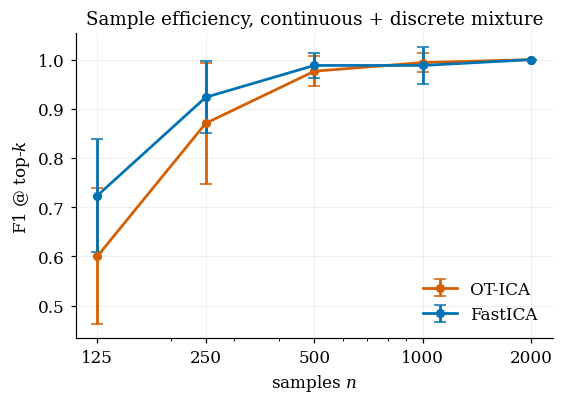

               mean    std
n    method               
125  FastICA  0.724  0.115
     OT-ICA   0.600  0.138
250  FastICA  0.924  0.074
     OT-ICA   0.871  0.123
500  FastICA  0.988  0.025
     OT-ICA   0.976  0.030
1000 FastICA  0.988  0.037
     OT-ICA   0.994  0.019
2000 FastICA  1.000  0.000
     OT-ICA   1.000  0.000


In [18]:
# =====================================================================
# B.5  SAMPLE-EFFICIENCY SWEEP (mixture regime)
# =====================================================================
N_GRID, sweep_rows = [125, 250, 500, 1000, 2000], []
for n in N_GRID:
    for s in SYN_SEEDS:
        Z, _ = simulate_sachs_lingam(n=n, regime="mixture", seed=s)
        Zc = Z - Z.mean(1, keepdims=True)
        for tag, fn in [("OT-ICA",  lambda: run_ot_ica(Zc, seed=s, n_restarts=96,
                                                       stages=8, batch_size=min(512, n))[:2]),
                        ("FastICA", lambda: run_fast_ica(Zc, seed=s))]:
            W, _S = fn()
            m = edge_metrics(w_to_B(W), A_TRUE)
            m.update(method=tag, n=n, seed=s)
            sweep_rows.append(m)
    print(f"n = {n} done")

sw = pd.DataFrame(sweep_rows)
fig, ax = plt.subplots(figsize=(5.6, 3.6))
for tag in ["OT-ICA", "FastICA"]:
    g = sw[sw.method == tag].groupby("n").f1
    ax.errorbar(N_GRID, g.mean(), yerr=g.std(), marker="o", ms=5, lw=1.8,
                capsize=4, color=PALETTE[tag], label=tag)
ax.set_xscale("log"); ax.set_xticks(N_GRID); ax.set_xticklabels(N_GRID)
ax.set_xlabel("samples $n$"); ax.set_ylabel("F1 @ top-$k$")
ax.set_title("Sample efficiency, continuous + discrete mixture")
ax.legend()
plt.savefig(f"{FIGDIR}/sachs_sample_efficiency.pdf"); plt.show()
print(sw.groupby(["n", "method"]).f1.agg(["mean", "std"]).round(3).to_string())

In [ ]:
# =====================================================================
# B.5b  SIGN TEST: OT-ICA vs FastICA F1, paired by seed, per sample size n
#      (supports the "Sample efficiency" paragraph, Appendix K.3.4)
# =====================================================================
sign_sw_rows = []
for n in N_GRID:
    r = sign_test_paired(sw[sw.n == n], "f1", lower_is_better=False)
    r["n"] = n
    sign_sw_rows.append(r)

sign_sw = pd.DataFrame(sign_sw_rows)[["n", "n_pairs", "wins_OT-ICA",
                                      "losses_OT-ICA", "p_value"]]
print("Sign test on F1, OT-ICA vs FastICA, paired by seed, per sample size:")
print(sign_sw.to_string(index=False))
print("\nWith only 10 paired seeds per n, a clean 10-0 sweep gives a two-sided "
      f"sign-test p-value of {binomtest(10, 10, 0.5, alternative='two-sided').pvalue:.4f} "
      "-- treat these as directional evidence consistent with the mean-F1 curve "
      "in the figure above, not as a substitute for it.")


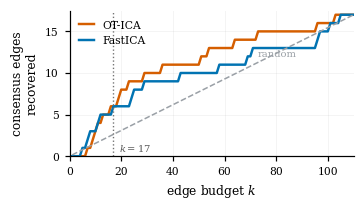

In [19]:
# =====================================================================
#  COMPACT MAIN-TEXT FIGURE: cumulative consensus edges vs. edge budget
# =====================================================================
off = ~np.eye(D, dtype=bool)
idx = np.argwhere(off)                                  # 110 candidate edges
ks  = np.arange(1, len(idx) + 1)

fig, ax = plt.subplots(figsize=(3.3, 1.85))
for tag, B in [("OT-ICA", B_ot_m), ("FastICA", B_fi_m)]:
    sc = np.abs(B)[idx[:, 0], idx[:, 1]]
    rk = np.argsort(-sc)
    hits = np.cumsum(A_TRUE[idx[rk, 0], idx[rk, 1]])
    ax.plot(ks, hits, lw=1.6, color=PALETTE[tag], label=tag)

ax.plot(ks, ks * K_TRUE / len(idx), ls="--", lw=1.0, color=C_GREY)
ax.axvline(K_TRUE, color="0.45", lw=0.9, ls=":")
ax.text(K_TRUE + 2, 0.6, "$k=17$", fontsize=6.5, color="0.35")
ax.text(88, 12.0, "random", fontsize=6.5, color=C_GREY, ha="right")

ax.set_xlabel("edge budget $k$", fontsize=8)
ax.set_ylabel("consensus edges\nrecovered", fontsize=8)
ax.set_xlim(0, len(idx)); ax.set_ylim(0, K_TRUE + 0.5)
ax.tick_params(labelsize=7)
ax.legend(fontsize=7, loc="upper left", frameon=False, handlelength=1.4)
ax.grid(alpha=0.15)
plt.tight_layout(pad=0.3)
plt.savefig(f"{FIGDIR}/sachs_topk_recovery.pdf", bbox_inches="tight", pad_inches=0.02)
plt.show()